## Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os 
import sys

# Add project root to path
sys.path.insert(0, os.path.abspath('..'))
from scripts.top_phrase import top_phrases

## Load data

In [2]:
df_clean = pd.read_csv('../data/processed/final_mobile_reviews.csv')

## Theme Distribution Per Bank

In [3]:
# Theme counts by bank
bank_theme_counts = (
    df_clean.groupby(['bank', 'identified_theme'])
            .size()
            .reset_index(name='count')
)

# Percentage within each bank
bank_theme_counts['percentage'] = (
    bank_theme_counts.groupby('bank')['count']
                     .transform(lambda x: round(100 * x / x.sum(), 2))
)

# Top themes per bank
bank_theme_counts.sort_values(['bank', 'count'], ascending=[True, False]).head(15)

,bank,identified_theme,count,percentage
4,Bank of Abyssinia,General Satisfaction,181,38.76
5,Bank of Abyssinia,Other,103,22.06
6,Bank of Abyssinia,Transaction Performance,96,20.56
0,Bank of Abyssinia,Account Access Issues,39,8.35
1,Bank of Abyssinia,Customer Support,15,3.21
7,Bank of Abyssinia,UI & User Experience,15,3.21
3,Bank of Abyssinia,General Dissatisfaction,13,2.78
2,Bank of Abyssinia,Feature Requests,5,1.07
12,Commercial Bank of Ethiopia,General Satisfaction,205,44.86
13,Commercial Bank of Ethiopia,Other,88,19.26


## Satisfaction Drivers

In [4]:
positive_reviews = df_clean[
    df_clean['sentiment_label'].isin(['POSITIVE', 'positive'])
]

positive_themes = (
    positive_reviews.groupby(['bank', 'identified_theme'])
                    .size()
                    .reset_index(name='count')
                    .sort_values(['bank', 'count'], ascending=[True, False])
)

positive_themes

,bank,identified_theme,count
4,Bank of Abyssinia,General Satisfaction,178
5,Bank of Abyssinia,Other,43
6,Bank of Abyssinia,Transaction Performance,15
1,Bank of Abyssinia,Customer Support,10
7,Bank of Abyssinia,UI & User Experience,7
0,Bank of Abyssinia,Account Access Issues,5
3,Bank of Abyssinia,General Dissatisfaction,2
2,Bank of Abyssinia,Feature Requests,1
12,Commercial Bank of Ethiopia,General Satisfaction,203
13,Commercial Bank of Ethiopia,Other,50


## Supporting positive review examples

In [5]:
positive_reviews[
    (positive_reviews['bank'] == 'Commercial Bank of Ethiopia') &
    (positive_reviews['identified_theme'].str.contains('UI', na=False))
][['review_text', 'rating']].head(5)

,review_text,rating
31,apps make life easy,5
57,easy secure user friend,5
94,good easy use,5
99,easy use good privacy,4
124,easy use,5


## Pain Points

In [6]:
negative_reviews = df_clean[
    df_clean['sentiment_label'].isin(['NEGATIVE', 'negative'])
]

negative_themes = (
    negative_reviews.groupby(['bank', 'identified_theme'])
                    .size()
                    .reset_index(name='count')
                    .sort_values(['bank', 'count'], ascending=[True, False])
)

negative_themes

,bank,identified_theme,count
6,Bank of Abyssinia,Transaction Performance,81
5,Bank of Abyssinia,Other,60
0,Bank of Abyssinia,Account Access Issues,34
3,Bank of Abyssinia,General Dissatisfaction,11
7,Bank of Abyssinia,UI & User Experience,8
1,Bank of Abyssinia,Customer Support,5
2,Bank of Abyssinia,Feature Requests,4
4,Bank of Abyssinia,General Satisfaction,3
14,Commercial Bank of Ethiopia,Transaction Performance,57
13,Commercial Bank of Ethiopia,Other,38


## Supporting negitive review examples

In [7]:
negative_reviews[
    (negative_reviews['bank'] == 'Dashen Bank') &
    (negative_reviews['identified_theme'].str.contains('Transaction', na=False))
][['review_text', 'rating']].head(5)

,review_text,rating
943,would helpful used transfer saved usable futur...,4
961,disappointed option transfer cash telebirr lim...,1
973,work,1
977,poor service always responding ever need trans...,1
978,recent update broken diesn allow take screen s...,2


## Cross-Bank Comparison

## Average Rating Per Bank

In [8]:
avg_rating = (
    df_clean.groupby('bank')['rating']
            .mean()
            .round(2)
            .reset_index()
)

avg_rating

,bank,rating
0,Bank of Abyssinia,3.55
1,Commercial Bank of Ethiopia,4.08
2,Dashen Bank,4.10


## Sentiment Distribution Per Bank

In [9]:
sentiment_dist = (
    df_clean.groupby(['bank', 'sentiment_label'])
            .size()
            .reset_index(name='count')
)

sentiment_dist['percentage'] = (
    sentiment_dist.groupby('bank')['count']
                  .transform(lambda x: round(100 * x / x.sum(), 2))
)

sentiment_dist

,bank,sentiment_label,count,percentage
0,Bank of Abyssinia,NEGATIVE,206,44.11
1,Bank of Abyssinia,POSITIVE,261,55.89
2,Commercial Bank of Ethiopia,NEGATIVE,140,30.63
3,Commercial Bank of Ethiopia,POSITIVE,317,69.37
4,Dashen Bank,NEGATIVE,138,29.49
5,Dashen Bank,POSITIVE,330,70.51


## Dominant Themes Per Bank

In [10]:
bank_theme_counts.sort_values(
    ['bank', 'count'],
    ascending=[True, False]
).groupby('bank').head(5)

,bank,identified_theme,count,percentage
4,Bank of Abyssinia,General Satisfaction,181,38.76
5,Bank of Abyssinia,Other,103,22.06
6,Bank of Abyssinia,Transaction Performance,96,20.56
0,Bank of Abyssinia,Account Access Issues,39,8.35
1,Bank of Abyssinia,Customer Support,15,3.21
12,Commercial Bank of Ethiopia,General Satisfaction,205,44.86
13,Commercial Bank of Ethiopia,Other,88,19.26
14,Commercial Bank of Ethiopia,Transaction Performance,86,18.82
8,Commercial Bank of Ethiopia,Account Access Issues,23,5.03
15,Commercial Bank of Ethiopia,UI & User Experience,23,5.03


## Find top phrases inside positive themes

In [11]:
top_phrases(df_clean, 'Commercial Bank of Ethiopia', 'General Satisfaction')

,phrase,count
8,nice app,12
1,best app,8
4,good app,8
6,good job,5
5,good application,4
3,excellent app,4
0,app thanks,2
2,best bank,2
7,great app,2
9,perfect app,2


In [12]:
top_phrases(df_clean, 'Commercial Bank of Ethiopia', 'Transaction Performance')


,phrase,count
1,app working,3
2,good work,3
9,work properly,3
5,safaricom network,3
8,update app,3
7,transfer telebirr,3
0,android version,2
3,pls make,2
4,properly transaction,2
6,transaction fee,2


In [13]:
top_phrases(df_clean, 'Bank of Abyssinia', 'General Satisfaction')

,phrase,count
6,good app,10
3,best app,10
0,amazing app,4
9,nice app,3
8,great boa,3
4,best bank,3
1,app ethiopia,2
2,bad better,2
5,best best,2
7,good application,2


In [14]:
top_phrases(df_clean, 'Bank of Abyssinia', 'Transaction Performance')

,phrase,count
6,mobile banking,5
1,app work,4
0,app slow,3
2,app working,3
4,fast app,3
3,developer option,3
5,fix problem,3
7,send money,3
8,transfer money,2
9,worst bank,2


In [15]:
top_phrases(df_clean, 'Dashen Bank', 'General Satisfaction')

,phrase,count
6,good app,22
3,best app,20
9,nice app,16
7,good job,4
4,dashen bank,3
0,app used,3
8,great app,3
1,app user,2
5,fantastic app,2
2,banking app,2


In [16]:
top_phrases(df_clean, 'Dashen Bank', 'Transaction Performance')

,phrase,count
6,mobile banking,6
1,dashen bank,5
0,banking app,3
2,fast secure,3
3,good app,3
4,long time,2
5,lot work,2
7,update working,2
8,use app,2
9,using app,2


## VISUALIZATION SETTINGS

In [17]:
sns.set_theme(style='whitegrid')

plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

## Sentiment Distribution by Bank (Stacked Bar Chart)

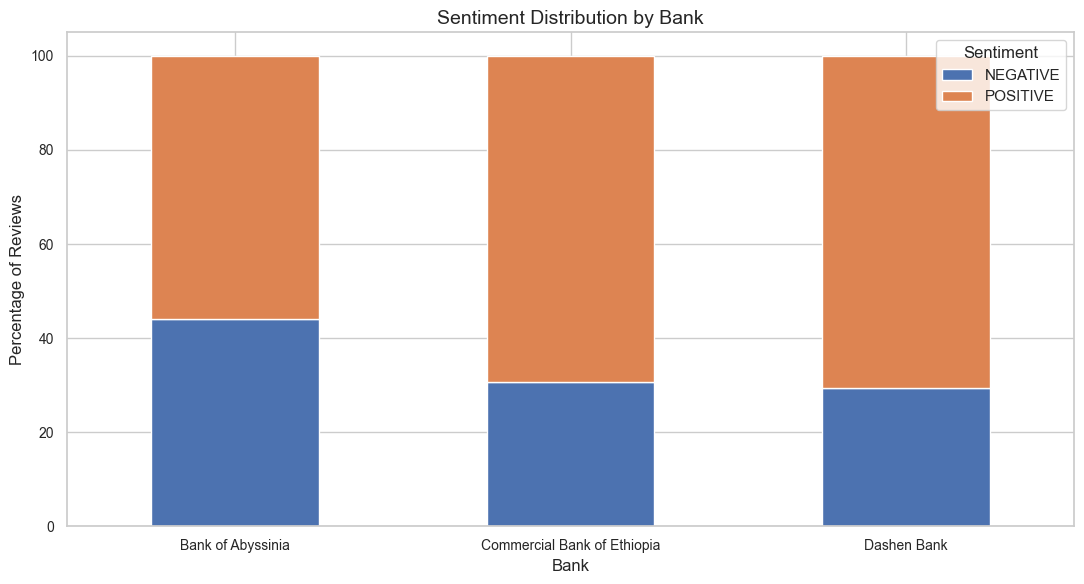

In [ ]:
# SENTIMENT DISTRIBUTION BY BANK
sentiment_counts = (
    df_clean.groupby(['bank', 'sentiment_label'])
            .size()
            .reset_index(name='count')
)

sentiment_pivot = sentiment_counts.pivot(
    index='bank',
    columns='sentiment_label',
    values='count'
).fillna(0)

# Convert to percentages
sentiment_pct = sentiment_pivot.div(
    sentiment_pivot.sum(axis=1),
    axis=0
) * 100

# Plot
sentiment_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(11,6)
)

plt.title('Sentiment Distribution by Bank')
plt.xlabel('Bank')
plt.ylabel('Percentage of Reviews')
plt.legend(title='Sentiment')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Rating Distribution Per Bank

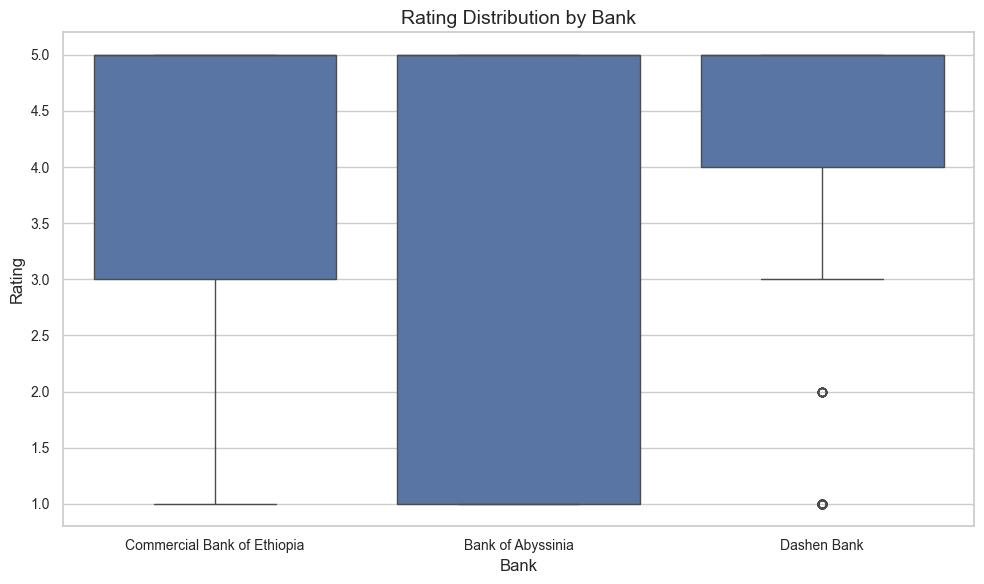

In [ ]:
# RATING DISTRIBUTION BOXPLOT
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_clean,
    x='bank',
    y='rating'
)

plt.title('Rating Distribution by Bank')
plt.xlabel('Bank')
plt.ylabel('Rating')

plt.tight_layout()
plt.show()

## Theme Frequency per Bank (Horizontal Bar Chart)

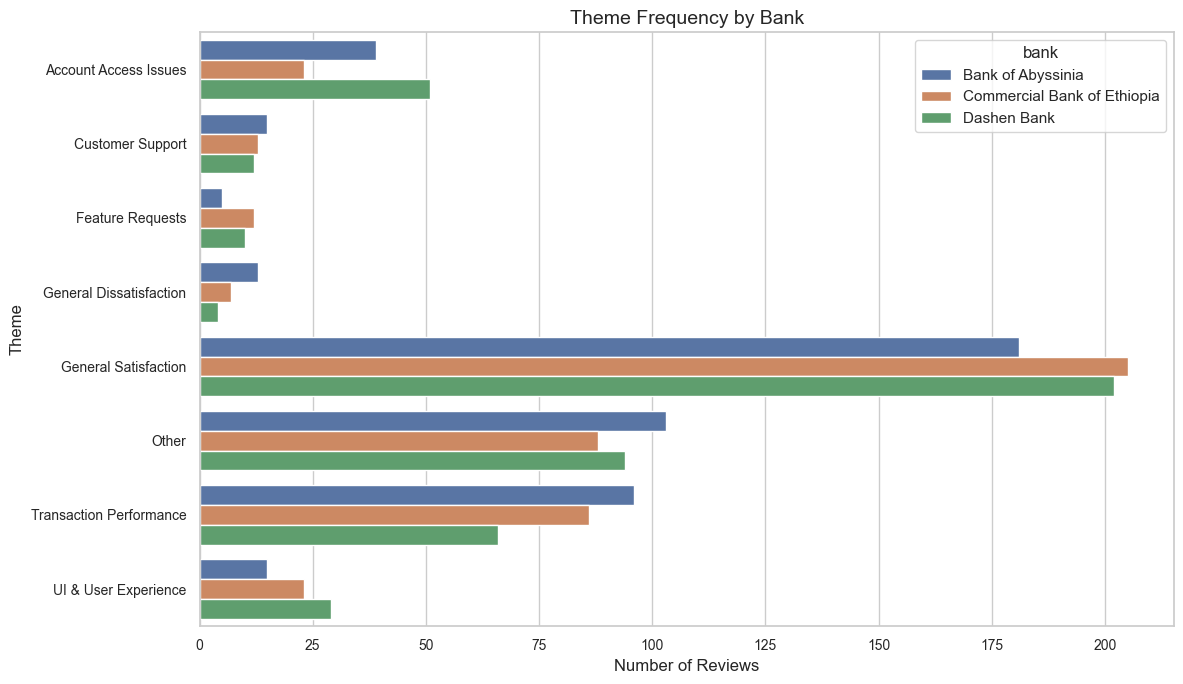

In [ ]:
# THEME FREQUENCY PER BANK
theme_counts = (
    df_clean.groupby(['bank', 'identified_theme'])
            .size()
            .reset_index(name='count')
)

plt.figure(figsize=(12,7))

sns.barplot(
    data=theme_counts,
    x='count',
    y='identified_theme',
    hue='bank'
)

plt.title('Theme Frequency by Bank')
plt.xlabel('Number of Reviews')
plt.ylabel('Theme')

plt.tight_layout()
plt.show()

## Top Keywords Per Bank

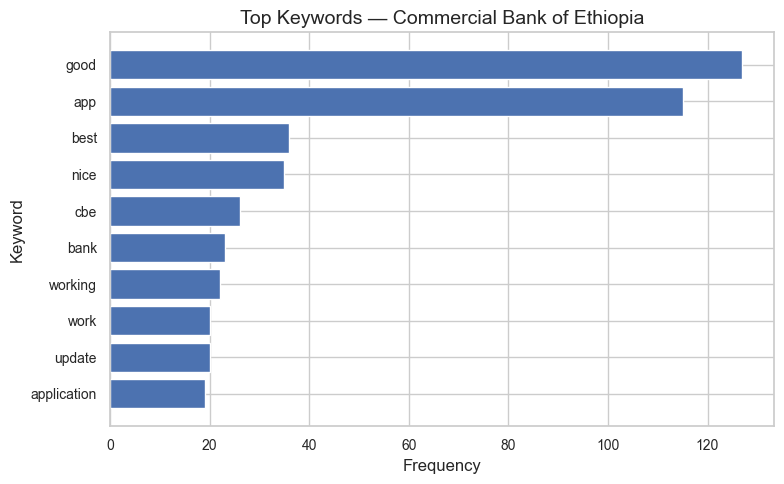

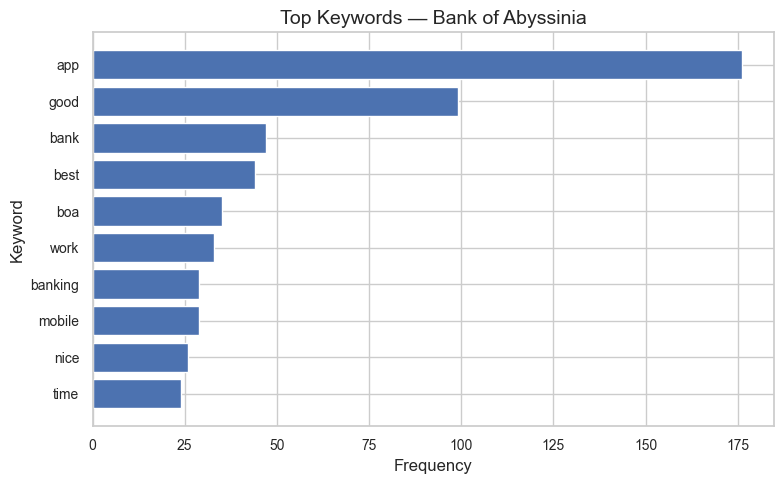

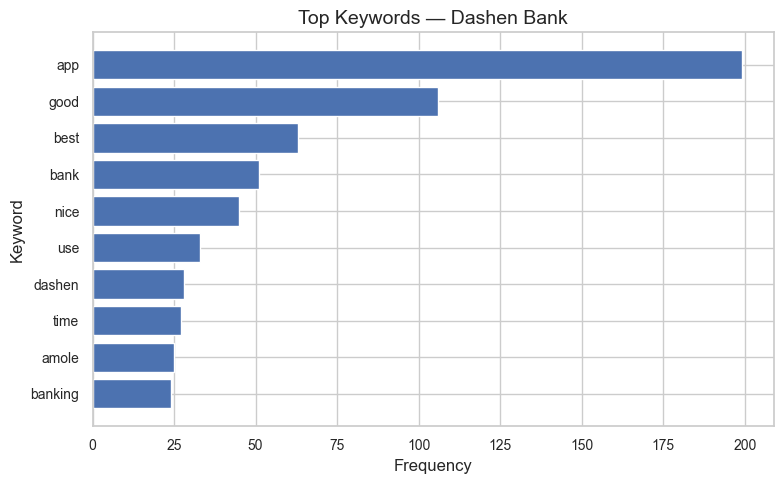

In [20]:
# TOP KEYWORDS PER BANK

from sklearn.feature_extraction.text import CountVectorizer

for bank in df_clean['bank'].unique():

    subset = df_clean[df_clean['bank'] == bank]

    vec = CountVectorizer(
        stop_words='english',
        max_features=10
    )

    X = vec.fit_transform(subset['review_text'])

    counts = X.toarray().sum(axis=0)

    keywords = pd.DataFrame({
        'keyword': vec.get_feature_names_out(),
        'count': counts
    }).sort_values('count', ascending=True)

    plt.figure(figsize=(8,5))

    plt.barh(
        keywords['keyword'],
        keywords['count']
    )

    plt.title(f'Top Keywords — {bank}')
    plt.xlabel('Frequency')
    plt.ylabel('Keyword')

    plt.tight_layout()
    plt.show()

## Sentiment Trend Over Time

C:\Users\hp\AppData\Local\Temp\ipykernel_8940\1738552381.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key='date', freq='M')


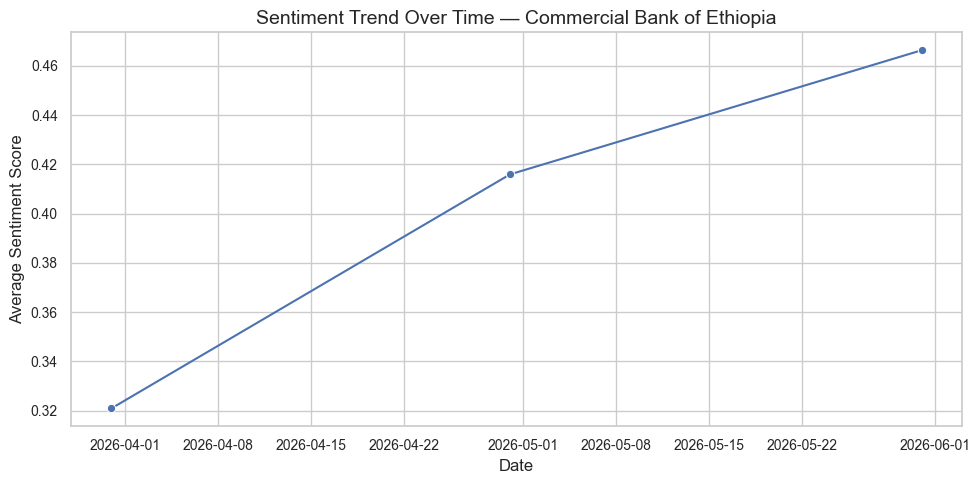

C:\Users\hp\AppData\Local\Temp\ipykernel_8940\1738552381.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key='date', freq='M')


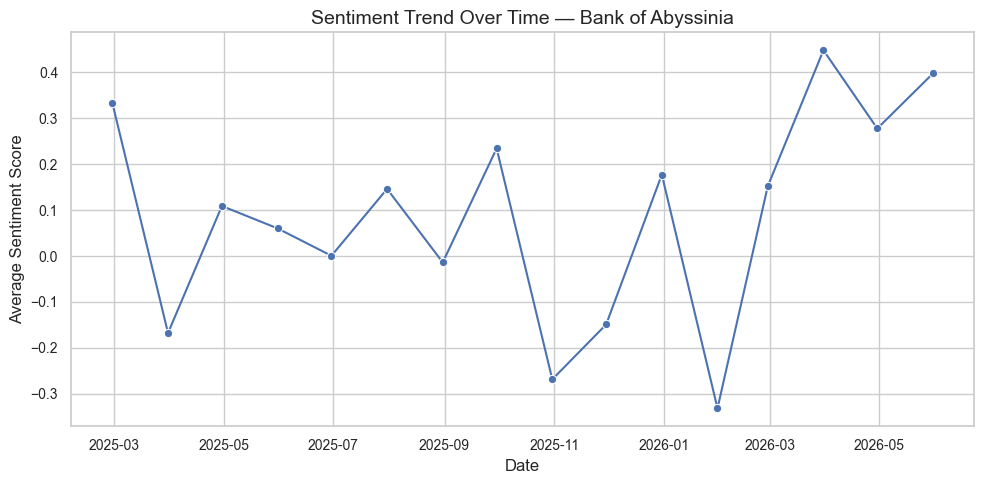

C:\Users\hp\AppData\Local\Temp\ipykernel_8940\1738552381.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key='date', freq='M')


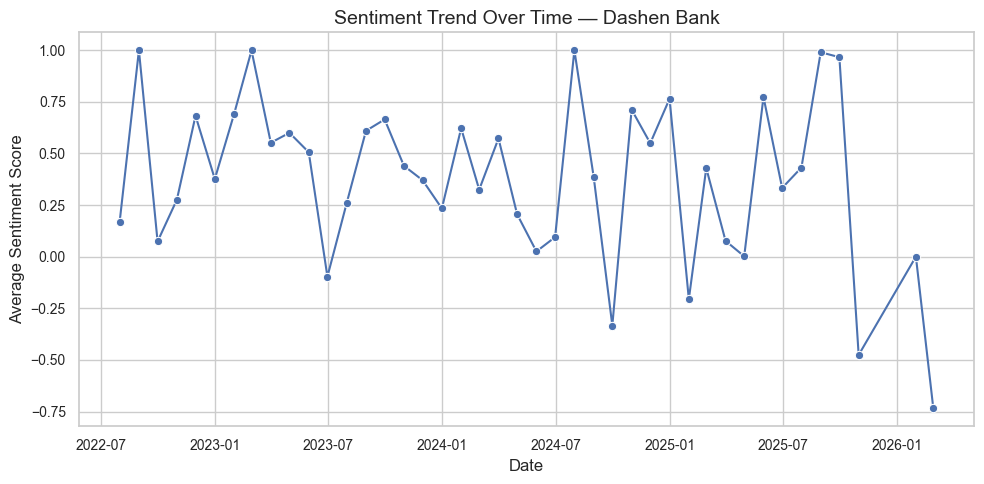

In [21]:

# SENTIMENT TREND OVER TIME (SEPARATE PER BANK)

df_clean['date'] = pd.to_datetime(df_clean['date'])

for bank in df_clean['bank'].unique():

    bank_df = df_clean[df_clean['bank'] == bank]

    monthly_sentiment = (
        bank_df.groupby(
            pd.Grouper(key='date', freq='M')
        )['sentiment_score']
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(10,5))

    sns.lineplot(
        data=monthly_sentiment,
        x='date',
        y='sentiment_score',
        marker='o'
    )

    plt.title(f'Sentiment Trend Over Time — {bank}')
    plt.xlabel('Date')
    plt.ylabel('Average Sentiment Score')

    plt.tight_layout()
    plt.show()

## Monthly Review Volume

C:\Users\hp\AppData\Local\Temp\ipykernel_8940\2979636983.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key='date', freq='M')


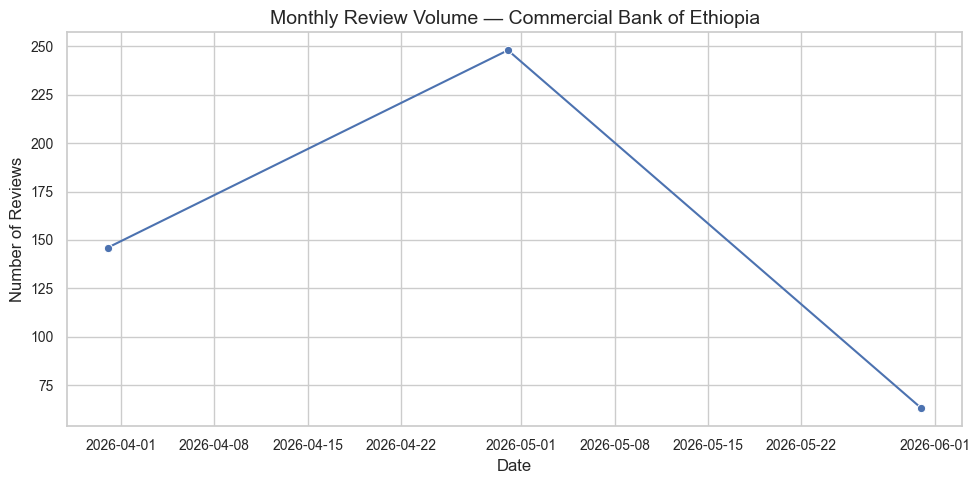

C:\Users\hp\AppData\Local\Temp\ipykernel_8940\2979636983.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key='date', freq='M')


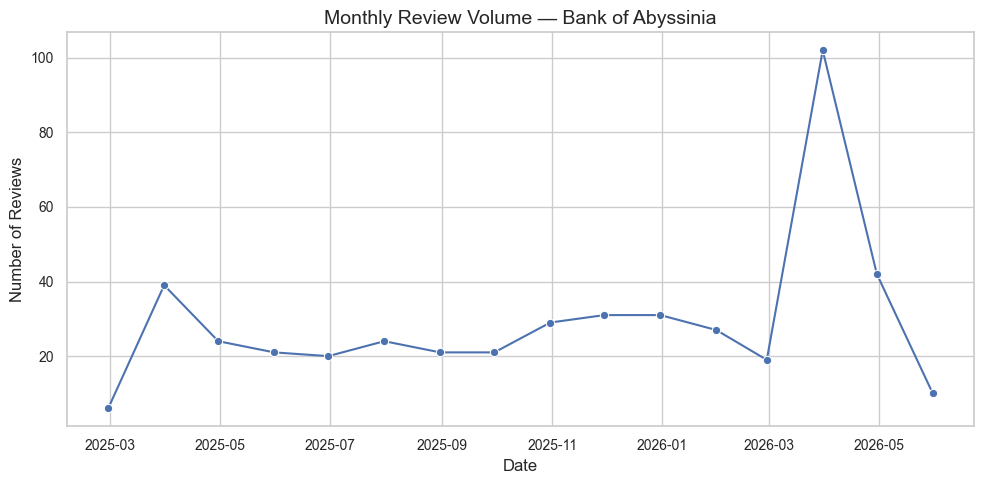

C:\Users\hp\AppData\Local\Temp\ipykernel_8940\2979636983.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key='date', freq='M')


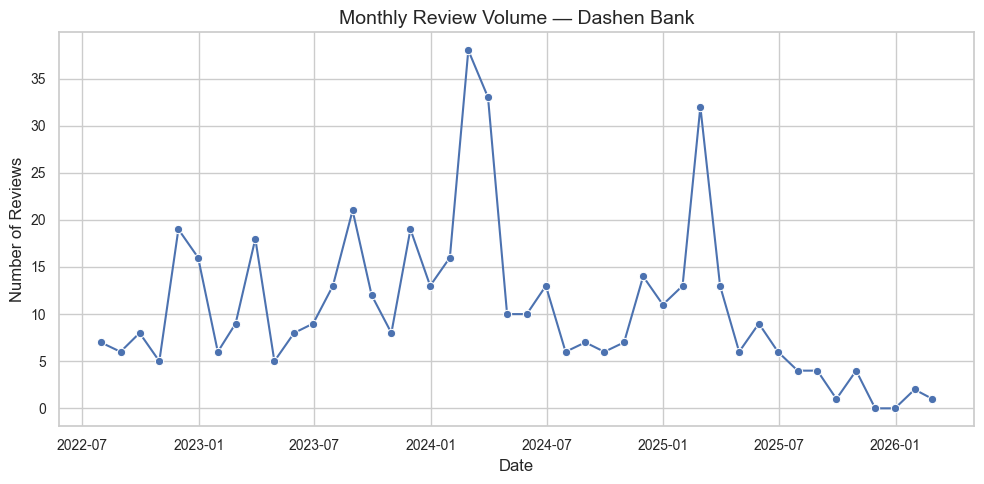

In [22]:
# MONTHLY REVIEW VOLUME

for bank in df_clean['bank'].unique():

    bank_df = df_clean[df_clean['bank'] == bank]

    monthly_reviews = (
        bank_df.groupby(
            pd.Grouper(key='date', freq='M')
        )
        .size()
        .reset_index(name='review_count')
    )

    plt.figure(figsize=(10,5))

    sns.lineplot(
        data=monthly_reviews,
        x='date',
        y='review_count',
        marker='o'
    )

    plt.title(f'Monthly Review Volume — {bank}')
    plt.xlabel('Date')
    plt.ylabel('Number of Reviews')

    plt.tight_layout()
    plt.show()

## Average Rating Comparison

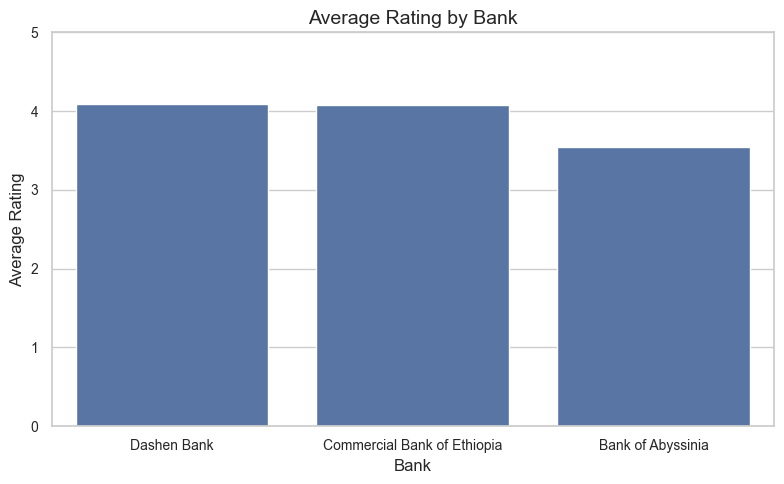

In [23]:
# AVERAGE RATING BY BANK
avg_rating = (
    df_clean.groupby('bank')['rating']
            .mean()
            .reset_index()
            .sort_values('rating', ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=avg_rating,
    x='bank',
    y='rating'
)

plt.title('Average Rating by Bank')
plt.xlabel('Bank')
plt.ylabel('Average Rating')

plt.ylim(0,5)

plt.tight_layout()
plt.show()